# Failure Case Extraction — coppie di immagini dove il modello ha sbagliato

Ricostruisce ESATTAMENTE lo split (train/val/test) usato nel training
originale (stesso `random_state`, stessa funzione di split), ricarica il
checkpoint scelto, e per ogni coppia del TEST set (mai vista in training
né early stopping) confronta lo score con la soglia EER già salvata nel
CSV delle metriche finali. Salva:
  - un CSV con tutte le coppie in errore (path, label, score, tipo errore)
  - una griglia PNG delle N coppie più "gravi" (score più lontano dalla soglia)

Configurazione tramite un JSON: modifica CONFIG_JSON nella cella sotto
(o carica da file con CONFIG_PATH) per scegliere backbone/loss/split.

In [1]:
import sys
sys.path.append('/home/lorenzo/Documenti/GitHub/HandVerify')

import os
import json
import ast
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from src.models import get_model
from src.data import create_dataloaders, create_cross_dataset_dataloaders
from src.data import SiameseDataset, ContrastiveDataset, TripletDataset
from src.utils import set_seed, get_device

## CONFIG

Modifica questo blocco (o punta `CONFIG_PATH` a un file .json con la
stessa struttura) per scegliere la configurazione da analizzare.

- `backbone`: uno tra efficientnet_b0/b1, mobilenet_v3_small/large, resnet18/34
- `loss_type`: 'bce' | 'contrastive' | 'triplet'
- `split`: 'iam_to_iam' | 'iam_to_rimes' | 'rimes_to_iam' | 'rimes_to_rimes'
- `top_n_per_type`: quante coppie (per tipo di errore) mostrare nella griglia PNG
- `results_root` / `dataset_root`: path base, coerenti col training originale

In [ ]:
CONFIG_PATH = None  # es. "./failure_config.json" — se valorizzato, sovrascrive CONFIG_JSON

CONFIG_JSON = """
{
    "backbone": "resnet18",
    "loss_type": "contrastive",
    "split": "iam_to_iam",

    "dataset_root": "/home/lorenzo/Documenti/GitHub/HandVerify/datasets/processed-handwritten",
    "results_root": "/home/lorenzo/Documenti/GitHub/HandVerify/results",

    "random_state": 42,
    "target_size": 448,
    "batch_size": 16,

    "val_size": 0.1,
    "test_size": 0.2,

    "model_hparams": {
        "in_channels": 1,
        "freeze_backbone_layers": 3,
        "dropout": 0.2,
        "embedding_dim": 32
    },

    "margin": {
        "contrastive": 1.0,
        "triplet": 0.5
    },

    "top_n_per_type": 2,
    "output_dir": "./failure_analysis"
}
"""

if CONFIG_PATH is not None and os.path.exists(CONFIG_PATH):
    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        CFG = json.load(f)
else:
    CFG = json.loads(CONFIG_JSON)

print(json.dumps(CFG, indent=2))

{
  "backbone": "resnet18",
  "loss_type": "contrastive",
  "split": "rimes_to_iam",
  "dataset_root": "/home/lorenzo/Documenti/GitHub/HandVerify/datasets/processed-handwritten",
  "results_root": "/home/lorenzo/Documenti/GitHub/HandVerify/results",
  "random_state": 42,
  "target_size": 448,
  "batch_size": 16,
  "val_size": 0.1,
  "test_size": 0.2,
  "model_hparams": {
    "in_channels": 1,
    "freeze_backbone_layers": 3,
    "dropout": 0.2,
    "embedding_dim": 32
  },
  "margin": {
    "contrastive": 1.0,
    "triplet": 0.5
  },
  "top_n_per_type": 2,
  "output_dir": "./failure_analysis"
}


## Costanti derivate dalla config

In [3]:
BACKBONE = CFG["backbone"]
LOSS_TYPE = CFG["loss_type"]
SPLIT = CFG["split"]  # es. "rimes_to_iam"
TRAIN_DS, TEST_DS = SPLIT.split("_to_")

RANDOM_STATE = CFG["random_state"]
TARGET_SIZE = CFG["target_size"]

DATASET_ROOT = Path(CFG["dataset_root"])
IAM_PATH = DATASET_ROOT / "iam_processed"
RIMES_PATH = DATASET_ROOT / "rimes_processed"

DATASET_PATH_BY_NAME = {"iam": IAM_PATH, "rimes": RIMES_PATH}
TRAIN_PATH = DATASET_PATH_BY_NAME[TRAIN_DS]
TEST_PATH_ROOT = DATASET_PATH_BY_NAME[TEST_DS]

EXP_NAME = f"{BACKBONE}_{LOSS_TYPE}_{SPLIT}"
CHECKPOINT_PATH = (
    Path(CFG["results_root"]) / LOSS_TYPE / f"{LOSS_TYPE}_experiments"
    / EXP_NAME / f"{EXP_NAME}_best.pth"
)
METRICS_CSV_PATH = (
    Path(CFG["results_root"]) / LOSS_TYPE / f"{LOSS_TYPE}_experiments"
    / EXP_NAME / f"{EXP_NAME}_final_metrics.csv"
)

OUTPUT_DIR = Path(CFG["output_dir"]) / EXP_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert CHECKPOINT_PATH.exists(), f"Checkpoint non trovato: {CHECKPOINT_PATH}"
assert METRICS_CSV_PATH.exists(), f"Metrics CSV non trovato: {METRICS_CSV_PATH}"

print(f"Esperimento:   {EXP_NAME}")
print(f"Checkpoint:    {CHECKPOINT_PATH}")
print(f"Metrics CSV:   {METRICS_CSV_PATH}")
print(f"Output dir:    {OUTPUT_DIR}")

set_seed(RANDOM_STATE)
device = get_device()

Esperimento:   resnet18_contrastive_rimes_to_iam
Checkpoint:    /home/lorenzo/Documenti/GitHub/HandVerify/results/contrastive/contrastive_experiments/resnet18_contrastive_rimes_to_iam/resnet18_contrastive_rimes_to_iam_best.pth
Metrics CSV:   /home/lorenzo/Documenti/GitHub/HandVerify/results/contrastive/contrastive_experiments/resnet18_contrastive_rimes_to_iam/resnet18_contrastive_rimes_to_iam_final_metrics.csv
Output dir:    failure_analysis/resnet18_contrastive_rimes_to_iam
Using device: cpu


## Ricostruzione ESATTA dello split test

Stessa funzione, stessi parametri, stesso `random_state` del training
originale: `create_dataloaders` per same-dataset (train_size implicito
1 - val_size - test_size, split 3 vie sui writer), `create_cross_dataset_dataloaders`
per cross-dataset (tutto il source in training, target diviso val/test).

NB: per il caso same-dataset lo split è a 3 vie (train/val/test) fatto
UNA VOLTA con `train_test_split(test_size=val_size+test_size)` poi
suddiviso ulteriormente — esattamente come in `dataloader_factory.py`,
quindi basta richiamare la stessa funzione con gli stessi argomenti per
ottenere bit-per-bit lo stesso test set.

In [4]:
DATASET_CLASS_BY_TYPE = {
    "bce": SiameseDataset,
    "contrastive": ContrastiveDataset,
    "triplet": TripletDataset,
}
dataset_class = DATASET_CLASS_BY_TYPE[LOSS_TYPE]

is_same_dataset = (TRAIN_DS == TEST_DS)

if is_same_dataset:
    print(f"📊 Same-dataset split: {TRAIN_DS} (val_size={CFG['val_size']}, test_size={CFG['test_size']})")
    _, _, test_loader, _, _, test_dataset = create_dataloaders(
        dataset_class,
        data_root=str(TRAIN_PATH),
        batch_size=CFG["batch_size"],
        num_workers=0,
        val_size=CFG["val_size"],
        test_size=CFG["test_size"],
        target_size=TARGET_SIZE,
        random_state=RANDOM_STATE,
        # positive_ratio/resample non influenzano la composizione del test
        # set (fisso, tutte le genuine + subset impostor coerente col
        # validate_comprehensive originale), ma vanno passati per costruire
        # correttamente l'oggetto dataset.
        positive_ratio=0.5,
        resample_negatives_every_n_epochs=0,
    )
else:
    print(f"📊 Cross-dataset split: {TRAIN_DS} → {TEST_DS} (val_size={CFG['val_size']} sul target)")
    # create_cross_dataset_dataloaders: val_size = frazione di target_root
    # riservata a VAL; qui vogliamo il TEST (il resto, 1 - val_size).
    # La funzione ritorna già (train, val, test) coerentemente.
    _, _, test_loader, _, _, test_dataset = create_cross_dataset_dataloaders(
        dataset_class,
        train_root=str(TRAIN_PATH),
        target_root=str(TEST_PATH_ROOT),
        batch_size=CFG["batch_size"],
        num_workers=0,
        val_size=CFG["val_size"],
        target_size=TARGET_SIZE,
        random_state=RANDOM_STATE,
        positive_ratio=0.5,
        resample_negatives_every_n_epochs=0,
    )

n_pairs = len(test_dataset.validation_pairs) if hasattr(test_dataset, "validation_pairs") \
    else len(test_dataset.samples)
print(f"\n✓ Test set ricostruito: {n_pairs} coppie")

📊 Cross-dataset split: rimes → iam (val_size=0.1 sul target)

Initializing TRAIN Contrastive Dataset
  Writers: 1500
  Positive ratio: 0.50
  Resample negatives every: 0 epoch(s)
  Generated 7175 genuine pairs (fixed)
  Generated 12721360 total impostor pairs (pool)
  Sampled 7175 impostors from pool of 12721360
  Created epoch dataset: 7175 genuine + 7175 impostors
  Actual positive ratio: 50.0%

Initializing VAL Contrastive Dataset
  Writers: 65
  Positive ratio: 0.50
  Resample negatives every: 0 epoch(s)
  Generated 207 genuine pairs (fixed)
  Generated 10089 total impostor pairs (pool)
  Sampled 207 impostors from pool of 10089
  Created epoch dataset: 207 genuine + 207 impostors
  Actual positive ratio: 50.0%

Initializing VAL Contrastive Dataset
  Writers: 592
  Positive ratio: 0.50
  Resample negatives every: 0 epoch(s)
  Generated 3844 genuine pairs (fixed)
  Generated 968471 total impostor pairs (pool)
  Sampled 3844 impostors from pool of 968471
  Created epoch dataset: 3844

## Verifica di coerenza contro Table 1 / il log originale

Confronta il conteggio di coppie appena ricostruito con quello atteso
(se lo conosci per questo split): se non coincide, lo split NON è
identico a quello del training originale (path dataset diverso, ordine
file diverso, o parametro random_state/val_size/test_size diverso) e i
risultati sottostanti NON sono affidabili.

In [5]:
genuine_count = sum(1 for *_ , label in
                     (test_dataset.validation_pairs if hasattr(test_dataset, "validation_pairs")
                      else test_dataset.samples) if label == 1.0)
impostor_count = n_pairs - genuine_count
print(f"Genuine: {genuine_count}  |  Impostor: {impostor_count}")
print("Confronta questi numeri con Table 1 / il log originale per questo split "
      "prima di fidarti dei risultati sotto.")

Genuine: 3844  |  Impostor: 3844
Confronta questi numeri con Table 1 / il log originale per questo split prima di fidarti dei risultati sotto.


## Caricamento modello dal checkpoint

In [4]:
model_hparams = dict(CFG["model_hparams"])
model = get_model(BACKBONE, model_type=LOSS_TYPE, **model_hparams)

state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device).eval()

print(f"✓ Caricato {LOSS_TYPE}/{BACKBONE} da {CHECKPOINT_PATH.name}")

use_embeddings = LOSS_TYPE in ("contrastive", "triplet")
margin = CFG["margin"].get(LOSS_TYPE) if use_embeddings else None
if use_embeddings:
    print(f"  (score = cosine similarity tra embedding; margin di training = {margin}, "
          f"non usato in valutazione ma riportato per riferimento)")

Total encoder layers: 9
  ❄️  Frozen 3 encoder layers
  ❄️  Frozen parameters: 3,264 / 11,170,240 (0.0%)
✓ Caricato contrastive/resnet18 da resnet18_contrastive_rimes_to_iam_best.pth
  (score = cosine similarity tra embedding; margin di training = 1.0, non usato in valutazione ma riportato per riferimento)


## Soglia EER — riletta dal CSV già prodotto per Table 4

Non ricalcolata: usiamo esattamente lo stesso valore già pubblicato nel
paper per questa configurazione, per garantire coerenza tra le coppie
marcate come errore qui e i numeri (EER, accuracy@EER, ecc.) già riportati.

In [5]:
metrics_df = pd.read_csv(METRICS_CSV_PATH)
eer_threshold = float(metrics_df["eer_threshold"].values[0])
eer_reported = float(metrics_df["eer"].values[0])
auc_reported = float(metrics_df["auc"].values[0])

print(f"EER threshold (da CSV): {eer_threshold:.4f}")
print(f"EER riportato:          {eer_reported:.4f} ({eer_reported*100:.2f}%)")
print(f"AUC riportato:          {auc_reported:.4f}")

EER threshold (da CSV): 0.8424
EER riportato:          0.1338 (13.38%)
AUC riportato:          0.9434


## Calcolo score su tutte le coppie del test set + identificazione errori

Stessa logica di `BaseTrainer.validate_comprehensive`: BCE usa l'output
diretto del modello (similarity in [0,1]); Contrastive/Triplet usano la
cosine similarity tra embedding L2-normalizzati.

In [8]:
from src.data.transforms import get_test_transforms
transform = get_test_transforms(TARGET_SIZE)

def load_img(path):
    img = Image.open(path).convert("L")
    return transform(img).unsqueeze(0).to(device)

@torch.no_grad()
def score_pair(img1_path, img2_path):
    img1 = load_img(img1_path)
    img2 = load_img(img2_path)
    if use_embeddings:
        emb1 = model(img1)
        emb2 = model(img2)
        return F.cosine_similarity(emb1, emb2).item()
    else:
        return model(img1, img2).item()

In [9]:
from tqdm import tqdm

In [ ]:
records = []
n_total = len(test_dataset.validation_pairs) if hasattr(test_dataset, "validation_pairs") \
    else len(test_dataset.samples)

for idx in tqdm(range(n_total), desc="Scoring test pairs"):
    img1_path, img2_path, label = test_dataset.get_validation_pair(idx)
    score = score_pair(img1_path, img2_path)

    predicted_genuine = score >= eer_threshold
    is_genuine = (label == 1.0)

    if is_genuine and not predicted_genuine:
        error_type = "false_reject"
    elif (not is_genuine) and predicted_genuine:
        error_type = "false_accept"
    else:
        error_type = None  # correttamente classificato

    records.append({
        "img1_path": img1_path,
        "img2_path": img2_path,
        "label": "genuine" if is_genuine else "impostor",
        "score": score,
        "threshold": eer_threshold,
        "margin_from_threshold": score - eer_threshold,
        "error_type": error_type,
    })

results_df = pd.DataFrame(records)
n_errors = results_df["error_type"].notna().sum()
print(f"\n✓ {n_total} coppie valutate, {n_errors} errori "
      f"({n_errors/n_total*100:.2f}%, atteso ≈ EER={eer_reported*100:.2f}% dato che "
      f"si valuta esattamente alla soglia EER)")

Scoring test pairs: 100%|██████████| 7688/7688 [37:56<00:00,  3.38it/s]


✓ 7688 coppie valutate, 1023 errori (13.31%, atteso ≈ EER=13.38% dato che si valuta esattamente alla soglia EER)


## Salvataggio CSV completo

In [9]:
csv_path = OUTPUT_DIR / f"{EXP_NAME}_pair_scores.csv"
results_df.to_csv(csv_path, index=False)
print(f"✓ Salvato CSV completo: {csv_path}")

errors_df = results_df[results_df["error_type"].notna()].copy()
errors_csv_path = OUTPUT_DIR / f"{EXP_NAME}_failure_pairs.csv"
errors_df.to_csv(errors_csv_path, index=False)
print(f"✓ Salvato CSV solo errori: {errors_csv_path} ({len(errors_df)} righe)")

✓ Salvato CSV completo: failure_analysis/resnet18_contrastive_rimes_to_iam/resnet18_contrastive_rimes_to_iam_pair_scores.csv
✓ Salvato CSV solo errori: failure_analysis/resnet18_contrastive_rimes_to_iam/resnet18_contrastive_rimes_to_iam_failure_pairs.csv (1023 righe)


In [10]:
csv_path = OUTPUT_DIR / f"{EXP_NAME}_pair_scores.csv"
assert csv_path.exists(), f"File non trovato: {csv_path} — esegui prima lo scoring."

results_df = pd.read_csv(csv_path)

# error_type è NaN per le righe corrette quando riletto da CSV (pandas
# converte None -> NaN in scrittura/lettura): .notna() sotto continua a
# funzionare identicamente a quando results_df veniva costruito a mano.
errors_df = results_df[results_df["error_type"].notna()].copy()

n_total = len(results_df)
n_errors = len(errors_df)

print(f"✓ Ricaricato da {csv_path}")
print(f"  {n_total} coppie totali, {n_errors} errori ({n_errors/n_total*100:.2f}%)")
print(f"  false_accept: {(errors_df['error_type']=='false_accept').sum()}")
print(f"  false_reject: {(errors_df['error_type']=='false_reject').sum()}")

✓ Ricaricato da failure_analysis/resnet18_contrastive_rimes_to_iam/resnet18_contrastive_rimes_to_iam_pair_scores.csv
  7688 coppie totali, 1023 errori (13.31%)
  false_accept: 508
  false_reject: 515


## Selezione dei fallimenti più "gravi"

- False accept più gravi: impostor con score più alto (più lontano
  sopra la soglia, il modello "ci ha creduto di più").
- False reject più gravi: genuine con score più basso (più lontano
  sotto la soglia).

In [11]:
TOP_N = CFG["top_n_per_type"]

worst_false_accepts = (
    errors_df[errors_df["error_type"] == "false_accept"]
    .sort_values("score", ascending=False)
    .head(TOP_N)
)
worst_false_rejects = (
    errors_df[errors_df["error_type"] == "false_reject"]
    .sort_values("score", ascending=True)
    .head(TOP_N)
)

print(f"False accepts trovati: {(errors_df['error_type']=='false_accept').sum()} "
      f"(mostrando i {len(worst_false_accepts)} più gravi)")
print(f"False rejects trovati: {(errors_df['error_type']=='false_reject').sum()} "
      f"(mostrando i {len(worst_false_rejects)} più gravi)")

worst_false_accepts.to_csv(OUTPUT_DIR / f"{EXP_NAME}_worst_false_accepts.csv", index=False)
worst_false_rejects.to_csv(OUTPUT_DIR / f"{EXP_NAME}_worst_false_rejects.csv", index=False)

False accepts trovati: 508 (mostrando i 2 più gravi)
False rejects trovati: 515 (mostrando i 2 più gravi)


## Griglia visuale delle coppie in errore (immagini affiancate)

Genero griglia false accepts...


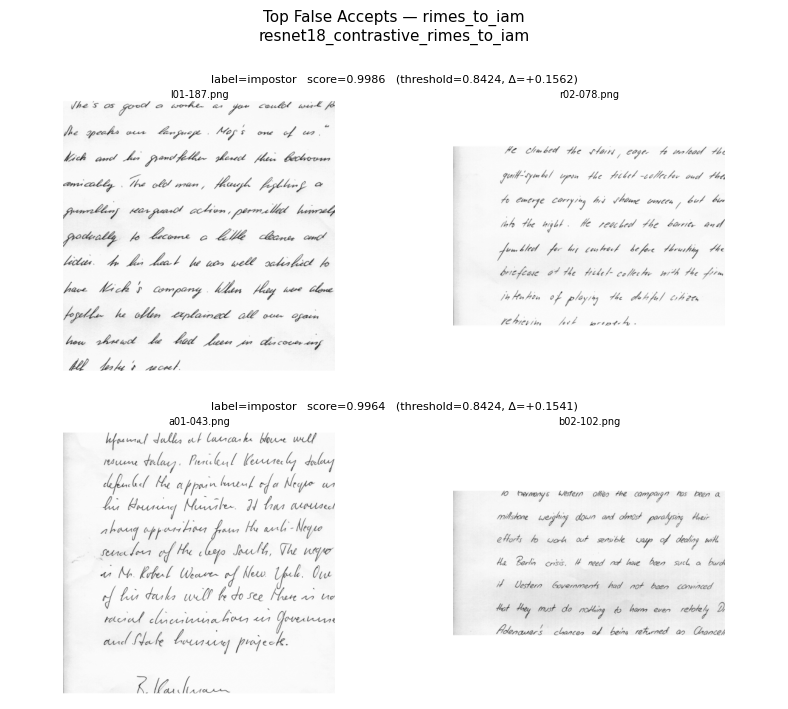

  ✓ Salvato: failure_analysis/resnet18_contrastive_rimes_to_iam/resnet18_contrastive_rimes_to_iam_false_accepts_grid.png
Genero griglia false rejects...


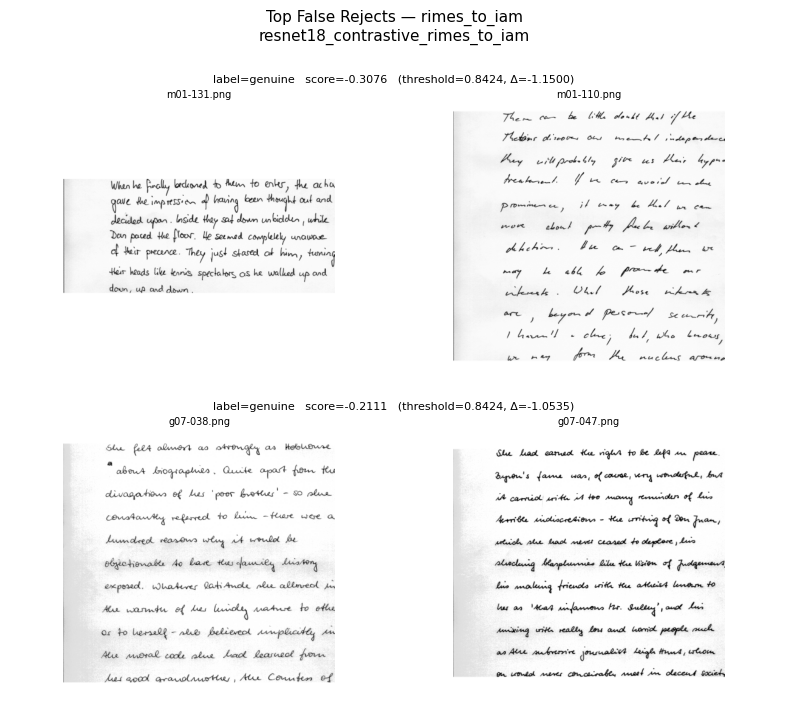

  ✓ Salvato: failure_analysis/resnet18_contrastive_rimes_to_iam/resnet18_contrastive_rimes_to_iam_false_rejects_grid.png


In [21]:
def plot_pair_grid(df, title, save_path, max_rows=12):
    df = df.head(max_rows)
    n = len(df)

    if n == 0:
        print(f"  (nessuna coppia per '{title}', salto il plot)")
        return

    fig = plt.figure(figsize=(8, 3.1 * n + 0.8))

    gs = fig.add_gridspec(
        nrows=n * 2,
        ncols=2,
        height_ratios=sum(([0.18, 1] for _ in range(n)), []),
        hspace=0.02,
        wspace=0.03
    )

    for i, (_, row) in enumerate(df.iterrows()):

        # ---------------------------------------------------------
        # Testo sopra le immagini
        # ---------------------------------------------------------
        text_ax = fig.add_subplot(gs[i * 2, :])
        text_ax.axis("off")

        text_ax.text(
            0.5,
            0.35,
            f"label={row['label']}   "
            f"score={row['score']:.4f}   "
            f"(threshold={row['threshold']:.4f}, "
            f"Δ={row['margin_from_threshold']:+.4f})",
            ha="center",
            va="center",
            fontsize=8
        )

        # ---------------------------------------------------------
        # Immagine 1
        # ---------------------------------------------------------
        ax1 = fig.add_subplot(gs[i * 2 + 1, 0])

        img1 = Image.open(row["img1_path"]).convert("L")

        ax1.imshow(img1, cmap="gray")
        ax1.axis("off")
        ax1.set_title(
            Path(row["img1_path"]).name,
            fontsize=7,
            pad=2
        )

        # ---------------------------------------------------------
        # Immagine 2
        # ---------------------------------------------------------
        ax2 = fig.add_subplot(gs[i * 2 + 1, 1])

        img2 = Image.open(row["img2_path"]).convert("L")

        ax2.imshow(img2, cmap="gray")
        ax2.axis("off")
        ax2.set_title(
            Path(row["img2_path"]).name,
            fontsize=7,
            pad=2
        )

    # Titolo generale
    fig.suptitle(
        f"{title}\n{EXP_NAME}",
        fontsize=11,
        y=0.995
    )

    plt.subplots_adjust(
        top=0.94,
        bottom=0.01,
        left=0.02,
        right=0.98
    )

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    print(f"  ✓ Salvato: {save_path}")


print("Genero griglia false accepts...")
plot_pair_grid(
    worst_false_accepts,
    f"Top False Accepts — {SPLIT}",
    OUTPUT_DIR / f"{EXP_NAME}_false_accepts_grid.png",
)

print("Genero griglia false rejects...")
plot_pair_grid(
    worst_false_rejects,
    f"Top False Rejects — {SPLIT}",
    OUTPUT_DIR / f"{EXP_NAME}_false_rejects_grid.png",
)

## Grad-CAM sulle coppie in errore più gravi
Per ciascuna delle coppie top-N (false accept / false reject) calcola
la heatmap Grad-CAM per capire su quali regioni della scrittura si è
concentrato il modello nel produrre quello score. Utile per distinguere
errori "ragionevoli" (il modello guarda i tratti giusti ma la scrittura
è ambigua) da errori "sospetti" (il modello guarda sfondo/rumore/bordi).

Genero griglia Grad-CAM per false accepts...


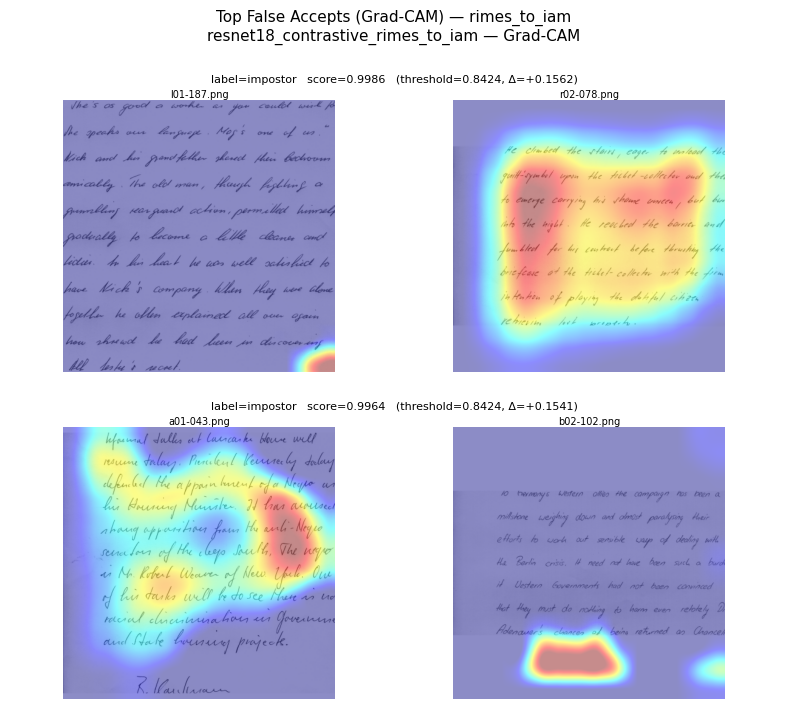

  ✓ Salvato: failure_analysis/resnet18_contrastive_rimes_to_iam/resnet18_contrastive_rimes_to_iam_false_accepts_gradcam.png
Genero griglia Grad-CAM per false rejects...


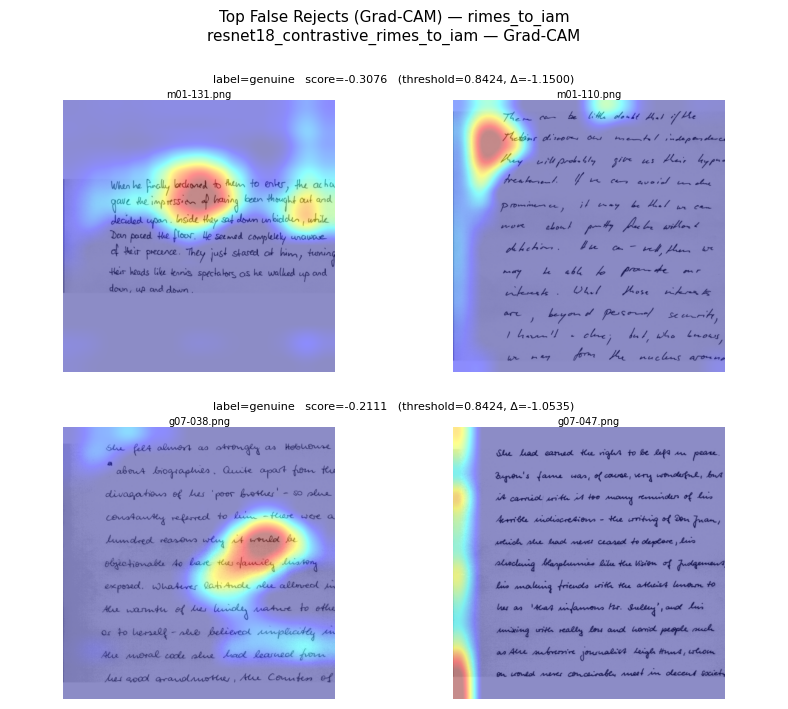

  ✓ Salvato: failure_analysis/resnet18_contrastive_rimes_to_iam/resnet18_contrastive_rimes_to_iam_false_rejects_gradcam.png


In [12]:
from src.interpretability import compute_pairwise_gradcam, overlay_cam_on_image

def load_gray_uint8(path):
    """Immagine 0-255 nella STESSA risoluzione vista dal modello (448x448),
    cosi' l'overlay della CAM e' coerente con cio' che il modello ha
    effettivamente processato."""
    img = Image.open(path).convert("L").resize((TARGET_SIZE, TARGET_SIZE))
    return np.array(img)

def plot_pair_grid_gradcam(df, title, save_path, max_rows=12):
    df = df.head(max_rows)
    n = len(df)
    if n == 0:
        print(f"  (nessuna coppia per '{title}', salto il plot)")
        return

    fig = plt.figure(figsize=(8, 3.1 * n + 0.8))
    gs = fig.add_gridspec(
        nrows=n * 2, ncols=2,
        height_ratios=sum(([0.18, 1] for _ in range(n)), []),
        hspace=0.02, wspace=0.03
    )

    for i, (_, row) in enumerate(df.iterrows()):
        text_ax = fig.add_subplot(gs[i * 2, :])
        text_ax.axis("off")
        text_ax.text(
            0.5, 0.35,
            f"label={row['label']}   score={row['score']:.4f}   "
            f"(threshold={row['threshold']:.4f}, Δ={row['margin_from_threshold']:+.4f})",
            ha="center", va="center", fontsize=8
        )

        img1_t = load_img(row["img1_path"])   # tensore preprocessato, gia' su device
        img2_t = load_img(row["img2_path"])

        cam1, cam2, score_check = compute_pairwise_gradcam(
            model, LOSS_TYPE, img1_t, img2_t, device
        )
        # sanity check: lo score del gradcam deve combaciare con quello già
        # salvato nel CSV per questa coppia (stesso modello, stesso input)
        assert abs(score_check - row["score"]) < 1e-3, (
            f"Score mismatch: gradcam={score_check:.4f} vs csv={row['score']:.4f}"
        )

        gray1 = load_gray_uint8(row["img1_path"])
        gray2 = load_gray_uint8(row["img2_path"])
        overlay1 = overlay_cam_on_image(gray1, cam1)
        overlay2 = overlay_cam_on_image(gray2, cam2)

        ax1 = fig.add_subplot(gs[i * 2 + 1, 0])
        ax1.imshow(cv2.cvtColor(overlay1, cv2.COLOR_BGR2RGB))
        ax1.axis("off")
        ax1.set_title(Path(row["img1_path"]).name, fontsize=7, pad=2)

        ax2 = fig.add_subplot(gs[i * 2 + 1, 1])
        ax2.imshow(cv2.cvtColor(overlay2, cv2.COLOR_BGR2RGB))
        ax2.axis("off")
        ax2.set_title(Path(row["img2_path"]).name, fontsize=7, pad=2)

    fig.suptitle(f"{title}\n{EXP_NAME} — Grad-CAM", fontsize=11, y=0.995)
    plt.subplots_adjust(top=0.94, bottom=0.01, left=0.02, right=0.98)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  ✓ Salvato: {save_path}")


import cv2  # serve solo qui per la conversione colore in overlay

print("Genero griglia Grad-CAM per false accepts...")
plot_pair_grid_gradcam(
    worst_false_accepts,
    f"Top False Accepts (Grad-CAM) — {SPLIT}",
    OUTPUT_DIR / f"{EXP_NAME}_false_accepts_gradcam.png",
)

print("Genero griglia Grad-CAM per false rejects...")
plot_pair_grid_gradcam(
    worst_false_rejects,
    f"Top False Rejects (Grad-CAM) — {SPLIT}",
    OUTPUT_DIR / f"{EXP_NAME}_false_rejects_gradcam.png",
)

## Riepilogo finale

In [11]:
print(f"\n{'='*70}")
print(f"RIEPILOGO — {EXP_NAME}")
print(f"{'='*70}")
print(f"Test set:              {n_total} coppie ({genuine_count} genuine, {impostor_count} impostor)")
print(f"Errori totali:         {n_errors} ({n_errors/n_total*100:.2f}%)")
print(f"  di cui false accept: {(errors_df['error_type']=='false_accept').sum()}")
print(f"  di cui false reject: {(errors_df['error_type']=='false_reject').sum()}")
print(f"\nOutput salvati in: {OUTPUT_DIR}/")
print(f"  - {EXP_NAME}_pair_scores.csv        (tutte le coppie con score)")
print(f"  - {EXP_NAME}_failure_pairs.csv      (solo errori)")
print(f"  - {EXP_NAME}_worst_false_accepts.csv")
print(f"  - {EXP_NAME}_worst_false_rejects.csv")
print(f"  - {EXP_NAME}_false_accepts_grid.png")
print(f"  - {EXP_NAME}_false_rejects_grid.png")
print(f"{'='*70}\n")


RIEPILOGO — resnet18_contrastive_rimes_to_iam
Test set:              7688 coppie (3844 genuine, 3844 impostor)
Errori totali:         1023 (13.31%)
  di cui false accept: 508
  di cui false reject: 515

Output salvati in: failure_analysis/resnet18_contrastive_rimes_to_iam/
  - resnet18_contrastive_rimes_to_iam_pair_scores.csv        (tutte le coppie con score)
  - resnet18_contrastive_rimes_to_iam_failure_pairs.csv      (solo errori)
  - resnet18_contrastive_rimes_to_iam_worst_false_accepts.csv
  - resnet18_contrastive_rimes_to_iam_worst_false_rejects.csv
  - resnet18_contrastive_rimes_to_iam_false_accepts_grid.png
  - resnet18_contrastive_rimes_to_iam_false_rejects_grid.png

